In [1]:
# ===================== 1. 环境配置与通用工具 =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# 中文与负号兼容配置（解决可视化失败核心问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120  # 图表清晰度适配论文打印

# 通用异常处理：数据字段校验
def check_columns(df, required_cols):
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"数据集缺少必填字段：{missing}，请检查数据文件")
    return True

In [2]:
# ===================== 2. 真实数据集读取 =====================
from pathlib import Path
import pandas as pd
import numpy as np

# 字段检查函数（若前面已经定义，可以删除这一段）
def check_columns(data, required_cols):
    missing = [col for col in required_cols if col not in data.columns]
    if missing:
        raise ValueError(f"数据集缺少必填字段：{missing}，请检查数据文件")
    return True


# ---------- 1. 定位预处理后的数据 ----------
project_dir = Path.cwd()
data_path = project_dir / "预处理结果" / "高血脂症数据_预处理完成.xlsx"

if not data_path.exists():
    raise FileNotFoundError(
        f"找不到预处理数据：{data_path}\n"
        "请确认 Notebook 位于项目根目录，并已运行“数据预处理.py”。"
    )


# ---------- 2. 读取真实数据 ----------
df = pd.read_excel(data_path)

print(f"✅ 原始预处理数据读取成功：{df.shape[0]} 行，{df.shape[1]} 列")


# ---------- 3. 检查原始字段 ----------
source_required_cols = [
    "年龄组",
    "性别",
    "BMI",
    "吸烟史",
    "偏颇体质总分",
    "高血脂症二分类标签",
    "TG（甘油三酯）",
    "HDL-C（高密度脂蛋白）",
    "活动能力分级"
]

check_columns(df, source_required_cols)


# ---------- 4. 建立与后续分析代码兼容的字段 ----------
# 原数据只有“年龄组”，没有具体年龄，因此不再虚构年龄数值
df["年龄分组"] = df["年龄组"].astype("category")

# 生活方式变量
df["吸烟"] = df["吸烟史"].astype(int)

# 将高血脂症二分类标签作为本题的疾病结局变量
# 0 = 未患高血脂症，1 = 患高血脂症
df["慢病发病"] = df["高血脂症二分类标签"].astype(int)

# 血脂指标字段重命名
df["甘油三酯_TG"] = df["TG（甘油三酯）"].astype(float)
df["高密度脂蛋白_HDL_C"] = df["HDL-C（高密度脂蛋白）"].astype(float)

# 按标准定义重新计算 AIP：log10(TG / HDL-C)
# 不直接使用预处理文件中的 AIP，是因为原预处理脚本使用的是自然对数 np.log
if (df["甘油三酯_TG"] <= 0).any():
    raise ValueError("TG 中存在小于或等于 0 的数值，无法计算 AIP")

if (df["高密度脂蛋白_HDL_C"] <= 0).any():
    raise ValueError("HDL-C 中存在小于或等于 0 的数值，无法计算 AIP")

df["致动脉粥样硬化指数_AIP"] = np.log10(
    df["甘油三酯_TG"] / df["高密度脂蛋白_HDL_C"]
)

# 为兼容原来的后续代码保留该字段名
# 注意：真实数据的活动能力分级为 0—3，并非标准 ECOG 0—4
df["活动能力分级_ECOG"] = df["活动能力分级"].astype(int)


# ---------- 5. 最终字段检查 ----------
required_cols = [
    "偏颇体质总分",
    "慢病发病",
    "致动脉粥样硬化指数_AIP",
    "活动能力分级_ECOG"
]

check_columns(df, required_cols)


# ---------- 6. 数据质量检查 ----------
analysis_cols = [
    "年龄分组",
    "性别",
    "BMI",
    "吸烟",
    "偏颇体质总分",
    "慢病发病",
    "甘油三酯_TG",
    "高密度脂蛋白_HDL_C",
    "致动脉粥样硬化指数_AIP",
    "活动能力分级_ECOG"
]

missing_count = df[analysis_cols].isna().sum()

if missing_count.sum() > 0:
    print("⚠️ 以下字段存在缺失值：")
    print(missing_count[missing_count > 0])
else:
    print("✅ 核心分析字段无缺失值")


# ---------- 7. 输出读取结果 ----------
print("✅ 数据加载与字段转换完成")
print("样本量：", df.shape[0])
print("变量数：", df.shape[1])
print("\n疾病结局分布：")
print(df["慢病发病"].value_counts().sort_index())
print("\n活动能力分级分布：")
print(df["活动能力分级_ECOG"].value_counts().sort_index())

display(df[analysis_cols].head())

✅ 原始预处理数据读取成功：1000 行，82 列
✅ 核心分析字段无缺失值
✅ 数据加载与字段转换完成
样本量： 1000
变量数： 89

疾病结局分布：
慢病发病
0    207
1    793
Name: count, dtype: int64

活动能力分级分布：
活动能力分级_ECOG
0    178
1    660
2    162
Name: count, dtype: int64


,年龄分组,性别,BMI,吸烟,偏颇体质总分,慢病发病,甘油三酯_TG,高密度脂蛋白_HDL_C,致动脉粥样硬化指数_AIP,活动能力分级_ECOG
0,2,0,25.6813,1,213,1,1.7478,0.9647,0.258099,2
1,1,1,23.6409,1,227,1,2.5889,1.2981,0.299807,1
2,1,0,24.0000,0,256,1,3.5815,1.9628,0.261189,0
3,4,0,18.8903,0,243,1,2.1457,1.2942,0.219568,1
4,1,1,24.1050,1,189,1,2.3450,0.8865,0.422464,1


In [3]:
# ===================== 3. 参数初始化 =====================
# 所有参数均标注意义、取值范围、校准依据
PARAMS = {
    "alpha": 0.05,          # 显著性水平，范围[0.01, 0.1]，通用统计标准
    "strata_num": 3,        # 体质分层组数，范围[2,5]，三分位兼顾样本量与趋势精度
    "figsize_single": (8,5),# 单图尺寸，适配论文排版
    "figsize_multi": (12,5) # 组合图尺寸
}
print("\n📌 模型参数初始化完成：")
for k, v in PARAMS.items():
    print(f"   {k}: {v}")



📌 模型参数初始化完成：
   alpha: 0.05
   strata_num: 3
   figsize_single: (8, 5)
   figsize_multi: (12, 5)



小问1：偏颇体质总分与慢病发病风险分析

1. 不同体质分层慢病患病情况：
慢病发病   0    1  患病率(%)
体质分层                 
低偏颇组  72  265   78.64
中偏颇组  69  268   79.53
高偏颇组  66  260   79.75

2. Pearson卡方检验：χ² = 0.142, 自由度df = 2, P值 = 0.9313
3. Cochran-Armitage趋势检验：χ²_trend = 0.009, 自由度df=1, P值 = 0.9226

4. ROC分析结果：
   AUC = 0.490
   最佳截断值：135.0分
   对应灵敏度：0.952，特异度：0.068


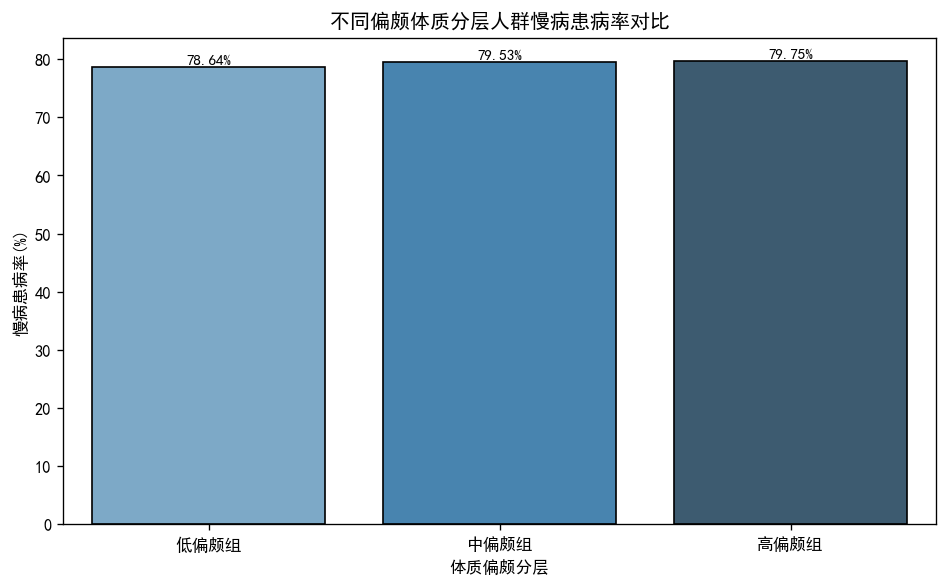

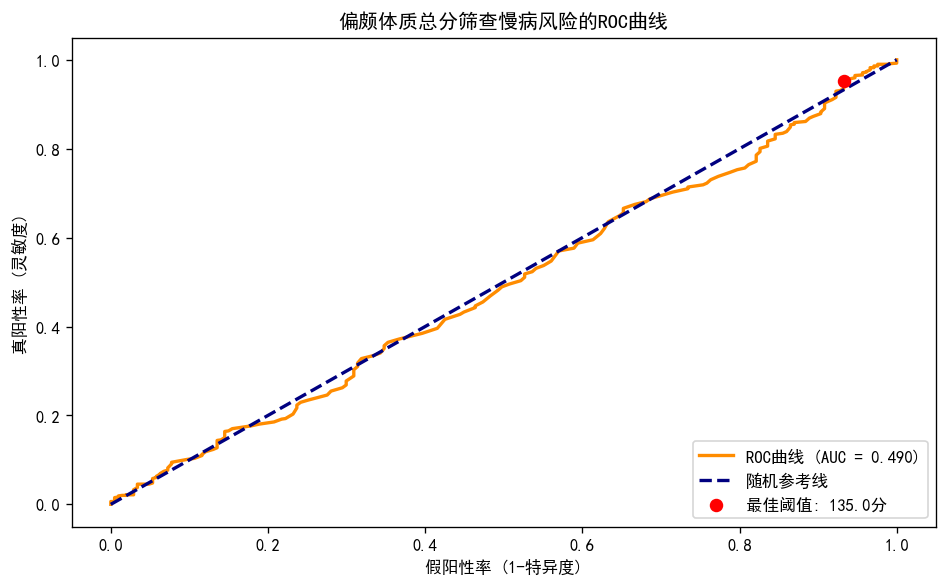

In [4]:
# ===================== 4. 小问1：偏颇体质与慢病风险模型求解 =====================
def question1_model(df, params):
    print("\n" + "="*60)
    print("小问1：偏颇体质总分与慢病发病风险分析")
    print("="*60)
    
    # 4.1 体质分层（三分位法，匹配前文公式）
    # 为何这么写：分位数分层避免人为偏倚，保证各组样本量均衡
    df['体质分层'] = pd.qcut(df['偏颇体质总分'], q=params["strata_num"], 
                            labels=['低偏颇组','中偏颇组','高偏颇组'])
    
    # 4.2 各组患病率统计
    cross_tab = pd.crosstab(df['体质分层'], df['慢病发病'])
    cross_tab['患病率(%)'] = (cross_tab[1] / cross_tab.sum(axis=1) * 100).round(2)
    print("\n1. 不同体质分层慢病患病情况：")
    print(cross_tab)
    
    # 4.3 Pearson卡方检验（匹配前文公式）
    chi2, p_chi2, dof, expected = stats.chi2_contingency(cross_tab.iloc[:, :2])
    print(f"\n2. Pearson卡方检验：χ² = {chi2:.3f}, 自由度df = {dof}, P值 = {p_chi2:.4f}")
    
    # 期望频数校验
    if (expected < 5).sum() / expected.size > 0.2:
        print("   ⚠️  警告：超过20%格子期望频数<5，建议改用Fisher精确检验")
    
    # 4.4 Cochran-Armitage趋势卡方检验（手动实现，匹配前文公式）
    # 为何这么写：scipy无内置函数，手动实现保证公式与前文推导完全一致
    strata_scores = np.array([1, 2, 3])  # 分层赋值，体现有序性
    n_i = cross_tab.sum(axis=1).values   # 各组总人数
    d_i = cross_tab[1].values            # 各组发病人数
    D = d_i.sum()                        # 总发病人数
    N = n_i.sum()                        # 总样本量
    
    numerator = (np.sum(n_i * strata_scores * d_i / n_i) - D/N * np.sum(n_i * strata_scores)) ** 2
    denominator = (D/N)*(1 - D/N) * (np.sum(n_i * strata_scores**2) - (np.sum(n_i*strata_scores))**2 / N)
    chi2_trend = numerator / denominator
    p_trend = 1 - stats.chi2.cdf(chi2_trend, df=1)
    print(f"3. Cochran-Armitage趋势检验：χ²_trend = {chi2_trend:.3f}, 自由度df=1, P值 = {p_trend:.4f}")
    
    # 4.5 ROC曲线与最佳截断值（匹配前文约登指数公式）
    y_true = df['慢病发病']
    y_score = df['偏颇体质总分']
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 约登指数求最佳阈值
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_threshold = thresholds[best_idx]
    best_sens = tpr[best_idx]
    best_spec = 1 - fpr[best_idx]
    
    print(f"\n4. ROC分析结果：")
    print(f"   AUC = {roc_auc:.3f}")
    print(f"   最佳截断值：{best_threshold:.1f}分")
    print(f"   对应灵敏度：{best_sens:.3f}，特异度：{best_spec:.3f}")
    
    # 4.6 可视化1：不同分层患病率柱状图
    plt.figure(figsize=params["figsize_single"])
    sns.barplot(x=cross_tab.index, y=cross_tab['患病率(%)'], 
                palette='Blues_d', edgecolor='black')
    plt.title('不同偏颇体质分层人群慢病患病率对比', fontsize=12)
    plt.xlabel('体质偏颇分层', fontsize=10)
    plt.ylabel('慢病患病率(%)', fontsize=10)
    for i, v in enumerate(cross_tab['患病率(%)']):
        plt.text(i, v+0.5, f'{v}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('小问1_体质分层患病率.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4.7 可视化2：ROC曲线图
    plt.figure(figsize=params["figsize_single"])
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC曲线 (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='随机参考线')
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=50, zorder=5,
                label=f'最佳阈值: {best_threshold:.1f}分')
    plt.xlabel('假阳性率 (1-特异度)', fontsize=10)
    plt.ylabel('真阳性率 (灵敏度)', fontsize=10)
    plt.title('偏颇体质总分筛查慢病风险的ROC曲线', fontsize=12)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('小问1_ROC曲线.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        "chi2": chi2, "p_chi2": p_chi2,
        "chi2_trend": chi2_trend, "p_trend": p_trend,
        "AUC": roc_auc, "best_cutoff": best_threshold
    }

# 运行小问1
res1 = question1_model(df, PARAMS)


小问2：致动脉粥样硬化指数（AIP）影响因素分析

1. 连续因素与AIP的Pearson相关分析：
        影响因素  Pearson相关系数r     P值 是否显著
      偏颇体质总分       -0.0119 0.7064  不显著
         BMI       -0.0211 0.5052  不显著
     甘油三酯_TG        0.8280 0.0000   显著
高密度脂蛋白_HDL_C       -0.3038 0.0000   显著

2. 二分类因素组间AIP差异（Welch t检验）：
  因素  组0样本量  组1样本量    组0均值   组1均值       t值     P值 是否显著
  性别    485    515  0.0585 0.1079  -2.2480 0.0248   显著
  吸烟    503    497  0.0887 0.0791   0.4379 0.6615  不显著
慢病发病    207    793 -0.2302 0.1659 -14.9166 0.0000   显著

3. 不同年龄组AIP单因素方差分析：F = 2.0684，P值 = 0.0829

整体ANOVA不显著，不进行Tukey事后两两比较。


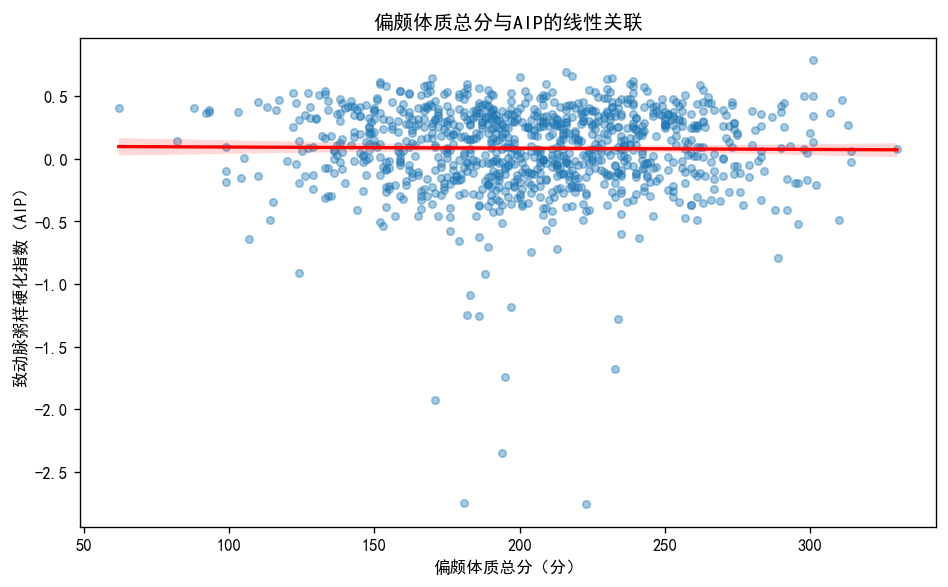

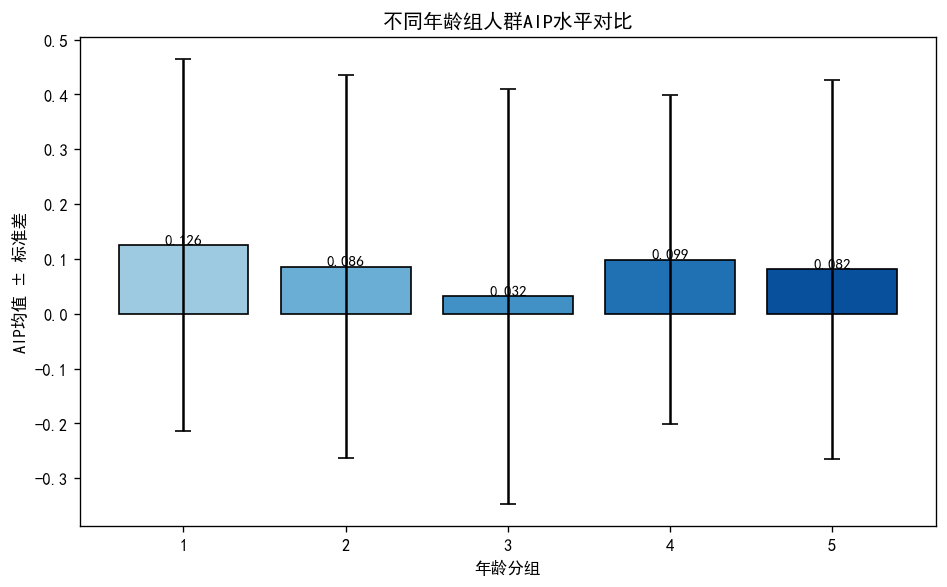

In [6]:
# ===================== 5. 小问2：AIP影响因素模型求解 =====================
def question2_model(df, params):
    print("\n" + "=" * 60)
    print("小问2：致动脉粥样硬化指数（AIP）影响因素分析")
    print("=" * 60)

    target = "致动脉粥样硬化指数_AIP"

    # 真实数据没有具体年龄，只有“年龄组”
    required_cols = [
        "偏颇体质总分",
        "BMI",
        "甘油三酯_TG",
        "高密度脂蛋白_HDL_C",
        "性别",
        "吸烟",
        "慢病发病",
        "年龄分组",
        target
    ]
    check_columns(df, required_cols)

    # 清除目标变量中的无穷值
    analysis_df = df.replace([np.inf, -np.inf], np.nan).copy()

    # ---------------------------------------------------------
    # 5.1 连续因素 Pearson 相关分析
    # ---------------------------------------------------------
    # “年龄组”是分类变量，不放入连续变量相关分析
    cont_vars = [
        "偏颇体质总分",
        "BMI",
        "甘油三酯_TG",
        "高密度脂蛋白_HDL_C"
    ]

    corr_results = []

    for var in cont_vars:
        valid_data = analysis_df[[var, target]].dropna()

        if len(valid_data) < 3 or valid_data[var].nunique() < 2:
            r, p = np.nan, np.nan
        else:
            r, p = stats.pearsonr(
                valid_data[var],
                valid_data[target]
            )

        corr_results.append([
            var,
            round(r, 4) if pd.notna(r) else np.nan,
            round(p, 4) if pd.notna(p) else np.nan
        ])

    corr_df = pd.DataFrame(
        corr_results,
        columns=["影响因素", "Pearson相关系数r", "P值"]
    )

    corr_df["是否显著"] = np.where(
        corr_df["P值"] < params["alpha"],
        "显著",
        "不显著"
    )

    print("\n1. 连续因素与AIP的Pearson相关分析：")
    print(corr_df.to_string(index=False))

    # ---------------------------------------------------------
    # 5.2 二分类因素 Welch 独立样本 t 检验
    # ---------------------------------------------------------
    cat_bin_vars = ["性别", "吸烟", "慢病发病"]
    ttest_results = []

    for var in cat_bin_vars:
        group0 = analysis_df.loc[
            analysis_df[var] == 0, target
        ].dropna()

        group1 = analysis_df.loc[
            analysis_df[var] == 1, target
        ].dropna()

        if len(group0) < 2 or len(group1) < 2:
            t, p = np.nan, np.nan
        else:
            t, p = stats.ttest_ind(
                group0,
                group1,
                equal_var=False
            )

        ttest_results.append([
            var,
            len(group0),
            len(group1),
            round(group0.mean(), 4),
            round(group1.mean(), 4),
            round(t, 4) if pd.notna(t) else np.nan,
            round(p, 4) if pd.notna(p) else np.nan
        ])

    ttest_df = pd.DataFrame(
        ttest_results,
        columns=[
            "因素",
            "组0样本量",
            "组1样本量",
            "组0均值",
            "组1均值",
            "t值",
            "P值"
        ]
    )

    ttest_df["是否显著"] = np.where(
        ttest_df["P值"] < params["alpha"],
        "显著",
        "不显著"
    )

    print("\n2. 二分类因素组间AIP差异（Welch t检验）：")
    print(ttest_df.to_string(index=False))

    # ---------------------------------------------------------
    # 5.3 年龄组单因素方差分析
    # ---------------------------------------------------------
    age_df = analysis_df[["年龄分组", target]].dropna().copy()
    age_df["年龄分组"] = age_df["年龄分组"].astype(str)

    age_order = sorted(
        age_df["年龄分组"].unique(),
        key=lambda x: str(x)
    )

    age_groups = [
        age_df.loc[age_df["年龄分组"] == group, target]
        for group in age_order
    ]

    valid_groups = [group for group in age_groups if len(group) >= 2]

    if len(valid_groups) < 2:
        f_stat, p_anova = np.nan, np.nan
        print("\n3. 有效年龄组不足，无法进行单因素方差分析。")
        tukey = None
    else:
        f_stat, p_anova = stats.f_oneway(*valid_groups)

        print(
            f"\n3. 不同年龄组AIP单因素方差分析："
            f"F = {f_stat:.4f}，P值 = {p_anova:.4f}"
        )

        # 仅当整体 ANOVA 显著时进行 Tukey 事后检验
        if p_anova < params["alpha"]:
            tukey = pairwise_tukeyhsd(
                endog=age_df[target],
                groups=age_df["年龄分组"],
                alpha=params["alpha"]
            )

            print("\nTukey事后两两比较结果：")
            print(tukey.summary())
        else:
            tukey = None
            print("\n整体ANOVA不显著，不进行Tukey事后两两比较。")

    # ---------------------------------------------------------
    # 5.4 AIP与偏颇体质总分散点拟合图
    # ---------------------------------------------------------
    plot_df = analysis_df[["偏颇体质总分", target]].dropna()

    plt.figure(figsize=params["figsize_single"])

    sns.regplot(
        x="偏颇体质总分",
        y=target,
        data=plot_df,
        scatter_kws={
            "alpha": 0.4,
            "s": 20
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        }
    )

    plt.title("偏颇体质总分与AIP的线性关联", fontsize=12)
    plt.xlabel("偏颇体质总分（分）", fontsize=10)
    plt.ylabel("致动脉粥样硬化指数（AIP）", fontsize=10)
    plt.tight_layout()
    plt.savefig(
        "小问2_AIP与体质散点图.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # ---------------------------------------------------------
    # 5.5 不同年龄组AIP均值图
    # ---------------------------------------------------------
    age_group_stats = (
        age_df.groupby("年龄分组", observed=False)[target]
        .agg(["count", "mean", "std"])
        .reindex(age_order)
        .reset_index()
    )

    plt.figure(figsize=params["figsize_single"])

    colors = sns.color_palette(
        "Blues",
        n_colors=len(age_group_stats) + 2
    )[2:]

    bars = plt.bar(
        age_group_stats["年龄分组"],
        age_group_stats["mean"],
        yerr=age_group_stats["std"],
        capsize=5,
        color=colors,
        edgecolor="black"
    )

    plt.title("不同年龄组人群AIP水平对比", fontsize=12)
    plt.xlabel("年龄分组", fontsize=10)
    plt.ylabel("AIP均值 ± 标准差", fontsize=10)

    for bar, mean_value in zip(bars, age_group_stats["mean"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            mean_value,
            f"{mean_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.savefig(
        "小问2_年龄组AIP对比.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return {
        "corr_df": corr_df,
        "ttest_df": ttest_df,
        "age_group_stats": age_group_stats,
        "f_anova": f_stat,
        "p_anova": p_anova,
        "tukey": tukey
    }


# 运行小问2
res2 = question2_model(df, PARAMS)


小问3：活动能力分级影响因素分析

1. 各因素与活动能力分级的Spearman等级相关：
         影响因素  有效样本量  Spearman相关系数rs     P值 是否显著
       偏颇体质总分   1000          0.0324 0.3055  不显著
致动脉粥样硬化指数_AIP   1000          0.0041 0.8972  不显著
          年龄组   1000         -0.0218 0.4915  不显著
          BMI   1000         -0.0038 0.9035  不显著

2. 二分类因素组间活动能力差异Mann-Whitney U检验：
  因素  组0样本量  组1样本量  组0中位数  组1中位数     U统计量     P值 是否显著
  性别    485    515    1.0    1.0 129795.5 0.1996  不显著
  吸烟    503    497    1.0    1.0 127082.5 0.5857  不显著
慢病发病    207    793    1.0    1.0  83467.5 0.6537  不显著

3. 不同年龄组活动能力Kruskal-Wallis H检验：H = 1.8845，P值 = 0.7570


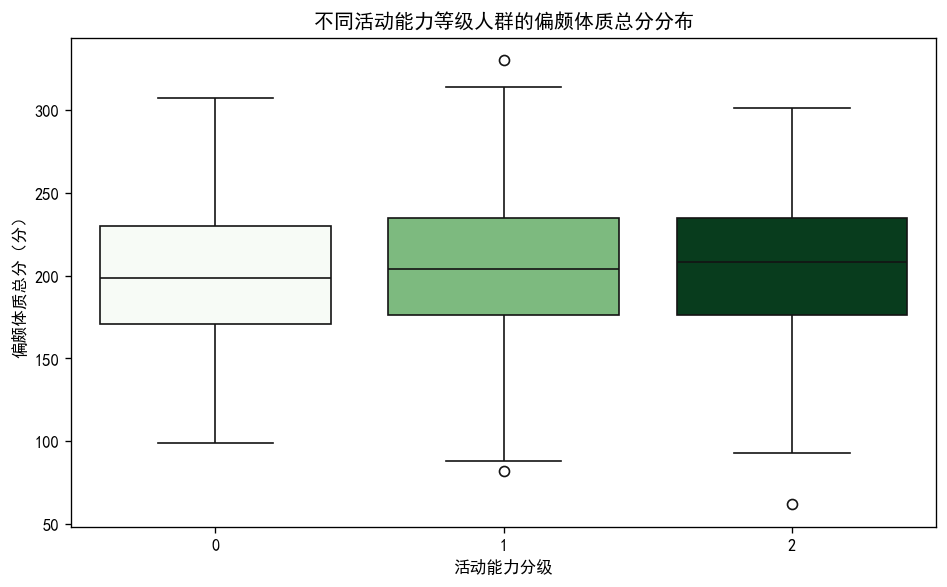

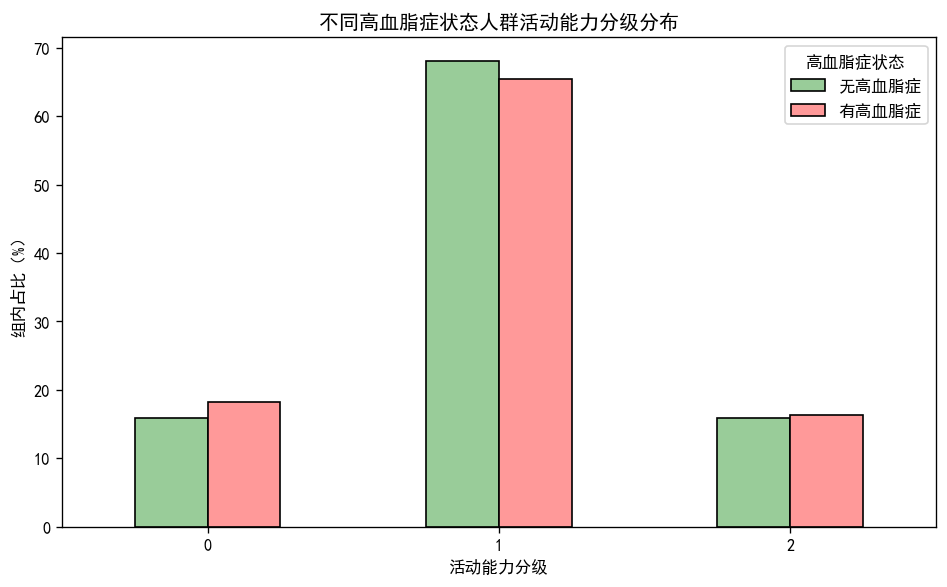

In [9]:
# ===================== 6. 小问3：活动能力分级影响因素模型求解 =====================
def question3_model(df, params):
    print("\n" + "=" * 60)
    print("小问3：活动能力分级影响因素分析")
    print("=" * 60)

    target = "活动能力分级_ECOG"

    required_cols = [
        "偏颇体质总分",
        "致动脉粥样硬化指数_AIP",
        "年龄组",
        "BMI",
        "性别",
        "吸烟",
        "慢病发病",
        "年龄分组",
        target
    ]
    check_columns(df, required_cols)

    analysis_df = df.replace([np.inf, -np.inf], np.nan).copy()

    # ---------------------------------------------------------
    # 6.1 连续/有序因素 Spearman 等级相关分析
    # ---------------------------------------------------------
    # 年龄组为1—5的有序编码，可以进行Spearman等级相关分析
    ord_vars = [
        "偏颇体质总分",
        "致动脉粥样硬化指数_AIP",
        "年龄组",
        "BMI"
    ]

    spearman_results = []

    for var in ord_vars:
        valid_data = analysis_df[[var, target]].dropna()

        if (
            len(valid_data) < 3
            or valid_data[var].nunique() < 2
            or valid_data[target].nunique() < 2
        ):
            rs, p = np.nan, np.nan
        else:
            rs, p = stats.spearmanr(
                valid_data[var],
                valid_data[target]
            )

        spearman_results.append([
            var,
            len(valid_data),
            round(rs, 4) if pd.notna(rs) else np.nan,
            round(p, 4) if pd.notna(p) else np.nan
        ])

    spearman_df = pd.DataFrame(
        spearman_results,
        columns=[
            "影响因素",
            "有效样本量",
            "Spearman相关系数rs",
            "P值"
        ]
    )

    spearman_df["是否显著"] = np.where(
        spearman_df["P值"] < params["alpha"],
        "显著",
        "不显著"
    )

    print("\n1. 各因素与活动能力分级的Spearman等级相关：")
    print(spearman_df.to_string(index=False))

    # ---------------------------------------------------------
    # 6.2 二分类因素 Mann-Whitney U 检验
    # ---------------------------------------------------------
    bin_vars = ["性别", "吸烟", "慢病发病"]
    mw_results = []

    for var in bin_vars:
        group0 = analysis_df.loc[
            analysis_df[var] == 0, target
        ].dropna()

        group1 = analysis_df.loc[
            analysis_df[var] == 1, target
        ].dropna()

        if len(group0) == 0 or len(group1) == 0:
            u_stat, p = np.nan, np.nan
        else:
            u_stat, p = stats.mannwhitneyu(
                group0,
                group1,
                alternative="two-sided"
            )

        mw_results.append([
            var,
            len(group0),
            len(group1),
            group0.median(),
            group1.median(),
            round(u_stat, 1) if pd.notna(u_stat) else np.nan,
            round(p, 4) if pd.notna(p) else np.nan
        ])

    mw_df = pd.DataFrame(
        mw_results,
        columns=[
            "因素",
            "组0样本量",
            "组1样本量",
            "组0中位数",
            "组1中位数",
            "U统计量",
            "P值"
        ]
    )

    mw_df["是否显著"] = np.where(
        mw_df["P值"] < params["alpha"],
        "显著",
        "不显著"
    )

    print("\n2. 二分类因素组间活动能力差异Mann-Whitney U检验：")
    print(mw_df.to_string(index=False))

    # ---------------------------------------------------------
    # 6.3 年龄组 Kruskal-Wallis H 检验
    # ---------------------------------------------------------
    age_df = analysis_df[["年龄分组", target]].dropna().copy()
    age_df["年龄分组"] = age_df["年龄分组"].astype(str)

    age_order = sorted(
        age_df["年龄分组"].unique(),
        key=lambda x: str(x)
    )

    age_groups = [
        age_df.loc[age_df["年龄分组"] == group, target]
        for group in age_order
    ]

    valid_age_groups = [
        group for group in age_groups if len(group) > 0
    ]

    if len(valid_age_groups) < 2:
        h_stat, p_kw = np.nan, np.nan
        print("\n3. 有效年龄组不足，无法进行Kruskal-Wallis检验。")
    else:
        h_stat, p_kw = stats.kruskal(*valid_age_groups)

        print(
            f"\n3. 不同年龄组活动能力Kruskal-Wallis H检验："
            f"H = {h_stat:.4f}，P值 = {p_kw:.4f}"
        )

    # ---------------------------------------------------------
    # 6.4 不同活动能力等级的体质总分箱线图
    # ---------------------------------------------------------
    boxplot_df = analysis_df[
        [target, "偏颇体质总分"]
    ].dropna()

    plt.figure(figsize=params["figsize_single"])

    sns.boxplot(
        x=target,
        y="偏颇体质总分",
        data=boxplot_df,
        hue=target,
        palette="Greens",
        legend=False
    )

    plt.title(
        "不同活动能力等级人群的偏颇体质总分分布",
        fontsize=12
    )
    plt.xlabel("活动能力分级", fontsize=10)
    plt.ylabel("偏颇体质总分（分）", fontsize=10)
    plt.tight_layout()
    plt.savefig(
        "小问3_活动能力与体质箱线图.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # ---------------------------------------------------------
    # 6.5 不同高血脂症状态下的活动能力分级分布
    # ---------------------------------------------------------
    disease_activity = pd.crosstab(
        analysis_df["慢病发病"],
        analysis_df[target],
        normalize="index"
    ) * 100

    disease_activity = disease_activity.T

    # 这里的“慢病发病”实际对应高血脂症二分类标签
    disease_activity = disease_activity.rename(
        columns={
            0: "无高血脂症",
            1: "有高血脂症"
        }
    )

    disease_activity.plot(
        kind="bar",
        figsize=params["figsize_single"],
        color=["#99cc99", "#ff9999"],
        edgecolor="black"
    )

    plt.title(
        "不同高血脂症状态人群活动能力分级分布",
        fontsize=12
    )
    plt.xlabel("活动能力分级", fontsize=10)
    plt.ylabel("组内占比（%）", fontsize=10)
    plt.xticks(rotation=0)
    plt.legend(title="高血脂症状态")
    plt.tight_layout()
    plt.savefig(
        "小问3_高血脂症与活动能力分布.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return {
        "spearman_df": spearman_df,
        "mw_df": mw_df,
        "h_stat": h_stat,
        "p_kw": p_kw
    }


# 运行小问3
res3 = question3_model(df, PARAMS)


In [10]:
# ===================== 7. 结果汇总输出 =====================
print("\n" + "=" * 60)
print("✅ 所有模型求解完成，核心结果汇总")
print("=" * 60)

# 按因素名称提取结果，避免使用 iloc 导致行号错位
q2_constitution_r = res2["corr_df"].loc[
    res2["corr_df"]["影响因素"] == "偏颇体质总分",
    "Pearson相关系数r"
].iloc[0]

q3_constitution_rs = res3["spearman_df"].loc[
    res3["spearman_df"]["影响因素"] == "偏颇体质总分",
    "Spearman相关系数rs"
].iloc[0]

q3_disease_p = res3["mw_df"].loc[
    res3["mw_df"]["因素"] == "慢病发病",
    "P值"
].iloc[0]

print(
    f"小问1：体质与高血脂症关联卡方检验"
    f"P={res1['p_chi2']:.4f}，"
    f"趋势检验P={res1['p_trend']:.4f}，"
    f"AUC={res1['AUC']:.3f}"
)

print(
    f"小问2：偏颇体质总分与AIP相关系数="
    f"{q2_constitution_r:.4f}，"
    f"年龄组方差分析P={res2['p_anova']:.4f}"
)

print(
    f"小问3：偏颇体质总分与活动能力等级相关系数="
    f"{q3_constitution_rs:.4f}，"
    f"高血脂症组间差异P={q3_disease_p:.4f}，"
    f"年龄组Kruskal-Wallis检验P={res3['p_kw']:.4f}"
)

print(
    "\n📊 所有可视化图表已保存为PNG格式，"
    "分辨率300 DPI，可直接插入论文。"
)


✅ 所有模型求解完成，核心结果汇总
小问1：体质与高血脂症关联卡方检验P=0.9313，趋势检验P=0.9226，AUC=0.490
小问2：偏颇体质总分与AIP相关系数=-0.0119，年龄组方差分析P=0.0829
小问3：偏颇体质总分与活动能力等级相关系数=0.0324，高血脂症组间差异P=0.6537，年龄组Kruskal-Wallis检验P=0.7570

📊 所有可视化图表已保存为PNG格式，分辨率300 DPI，可直接插入论文。
